### 강화학습으로 Cart Pole 버티기
-  목표
    - 200개의 step(시간) 단계 동안 Pole이 넘어지지 않고 유지하기
- 종료
    - Pole이 (수직으로부터 ±12도 이상으로) 기울거나 카트가 환경 밖으로 벗어나거나 최대 시간 단계인 200에 도달한 경우

In [2]:
# cart pole을 위한 install
!pip install gymnasium[classic-control]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.8 MB/s eta 0:00:00


### 환경 설정 한 값 기억하기
| 상태요소 | 구간수 | 범위 |
| --- | --- | --- |
| 카트위치 | 6 | -2.4 ~ 2.4|
| 카트 속도 | 12 | -3.0 ~ 3.0|
| 막대 기울기 | 6 | -0.5~ 0.5 |
| 막대각 속도 | 12 | -2.0 ~ 2.0 |


In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle # 도형
from matplotlib.animation import FuncAnimation # 프레임을 애니메이션화
from IPython.display import HTML # 애니메이션을 HTML로 표시 - jupyter용

# 환경 생성 하기
env = gym.make("CartPole-v1")
print(env.observation_space) # 관측값
#Box([-4.8(cart위치) -inf(cart속도)  -0.41887903(Pole각도) -inf(Pole각 속도)],[4.8(cart위치) inf(cart속도) 0.41887903(Pole각도) inf(Pole각 속도)], (4,), float32)
print(env.action_space.n) # action 2가지

# 연속형 데이터를 이산데이터로 변경해줘야함 : 무한대(inf) 처리가 어렵기 때문
# Q-tabel(observation_space) : 공간 범위 인위적 실험공간 생성
obs_space_low = np.array([-2.4, -3.0, -0.5, -2.0])
obs_space_high = np.array([2.4, 3.0, 0.5, 2.0])

# 이산적인 데이터 만들어주기 위해서 실험공간을 칸으로 나눠줘야함
# 상태 공간 이산화 수준 결정 - 각 상태 차원을 몇 개의 구간으로 나눌지를 결정해야함.
state_bins = [6, 12, 6, 12]

# q_tabel의 초기화
q_tabel = np.zeros(state_bins + [env.action_space.n])
print(q_tabel.shape) # (6, 12, 6, 12, 2)
# print(q_tabel)
print(6 * 12 * 6 * 12 * 2) # 10368의 state


Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
2
(6, 12, 6, 12, 2)
10368


In [4]:
# 연속적인 값(실수)을 몇 개의 고정된 구간(bin)으로 나눠 이산적인(정수) 인덱스로 반환하는 함수 생성
  # state(카트위치, 카트속도, 막대각, 막대각 속도)의 각 요소가 관측값 중 어디에 위치하는지 비율로 변환
  #-> 다시 정수화 하는 작업(정규화 공식 사용 (x-x.min)/(x.max-x.min))
def discretize_state(state):
  retios = (state - obs_space_low) / (obs_space_high - obs_space_low)
  # print('retios : ', retios)
  # 이산적으로 바꾸기
  discrete = (retios * state_bins).astype(int)
  # print('discrete : ', discrete)

  return tuple(np.clip(discrete, 0, np.array(state_bins) - 1))

# # clip 이란? : 제한된 범위 내의 수치 얻기
# a = np.array([-2, 0, 3, 7, 10])
# result = np.clip(a, 0, 5) # 대상, min, max
# print(result)

# ex_state = np.array([1.0, 0.5, 0.5, -1.0])
# dis_index = discretize_state(ex_state)
# print('Q-Table 인덱스 : ', dis_index) # (4, 7, 5, 3)

In [5]:
# 하이퍼 파라미터 설정
alpha = 0.1
gammer = 0.99
epsilon = 1.0
epsilon_decay = 0.999
epsilon_min = 0.05
episodes = 1000

reward_list = [] # 에피소드에서 받은 총 보상 기록
trajectories = [] # 위치정보(궤적)를 저장 - 애니메이션을 위해
best_reward = 0 # 지금까지 달성한 최고의 총 보상을 누적

In [6]:
# 에피소드 만큼 반복
for ep in range(episodes):
  obs, _ = env.reset()
  # print("obs : ", obs) # [ 0.00037246 -0.01156355 -0.00022936  0.00105786]
  state = discretize_state(obs)
  # print('state : ', state) (3, 5, 2, 6)
  total_reward = 0
  trajectory = []

  for step in range(200):
    # 행동선택 -> 새로운상태, 보상, 종료여부 반환 -> Q-tabel 갱신 -> 상태 갱신
    if np.random.rand() < epsilon:
      # 무작위 행동을 선택 (탐험)
      action = env.action_space.sample()
    else:
      # 이용
      action = np.argmax(q_tabel[state])

    # print("action :", action)

    # 주어진 action으로 환경 내에서 실행
    next_obs, reward, terminated, truncated, _ = env.step(action)
    # print(next_obs, reward, terminated, truncated)


    done = terminated or truncated
    next_state = discretize_state(next_obs)
    best_next_q = np.max(q_tabel[next_state]) # 미래 가치 계산
    # print('best_next_q :', best_next_q)

    # Q-Tabel갱신 : MDP가 적용(벨만방정식 사용)
    q_tabel[state + (action,)] += alpha * (reward + gammer * best_next_q - q_tabel[state + (action,)])

    state = next_state
    obs = next_obs # 원래 상태값도 갱신(시각화 용)

    total_reward += reward
    trajectory.append(obs.copy())

    if done: break

  reward_list.append(total_reward)

  # 향상된 보상 출력
  if total_reward > best_reward:
    best_reward = total_reward # 새로운 보상이 크므로 best_reward는 갱신
    print(f'Episode : {ep} : Reward improved to {total_reward}')

  # 10 에피소드 마다 위치정보(궤적) 저장
  if ep % 10 == 0:
    trajectories.append(trajectory)

  # epsilon 감소
  if epsilon > epsilon_min:
    epsilon *= epsilon_decay

Episode : 0 : Reward improved to 20.0
Episode : 5 : Reward improved to 53.0
Episode : 106 : Reward improved to 66.0
Episode : 125 : Reward improved to 69.0
Episode : 208 : Reward improved to 80.0
Episode : 347 : Reward improved to 86.0
Episode : 493 : Reward improved to 88.0
Episode : 518 : Reward improved to 100.0
Episode : 642 : Reward improved to 117.0
Episode : 683 : Reward improved to 121.0
Episode : 796 : Reward improved to 130.0
Episode : 798 : Reward improved to 158.0
Episode : 801 : Reward improved to 168.0


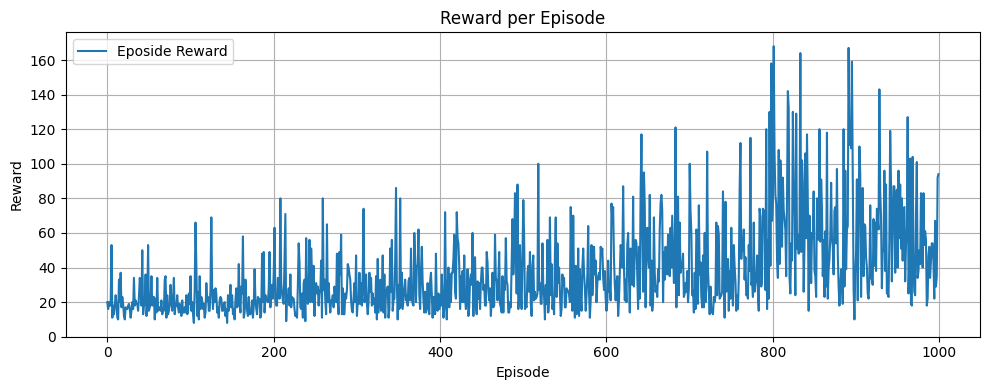

In [7]:
# 보상 그래프 시각화
plt.figure(figsize=(10, 4))
plt.plot(reward_list, label='Eposide Reward')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward per Episode')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# 저장된 궤적 정보로 애니메이션 실행
flat_states = [] # 여러 에피소드의 궤적을 한줄로 펼쳐 저장

episode_labels = []
episode_numbers = list(range(0, episodes, 10))
# print(episode_numbers) # [0, 10, 20, 30,

# 시각화 목적의 데이터 평탄화 라벨링
for i, traj in enumerate(trajectories):
  # print(len(traj)) # 각 에피소드마다 수행한 횟수
  flat_states.extend(traj)
  episode_labels.extend([episode_numbers[i]] * len(traj))
  # print("episode_labels : ", episode_labels)

frame_count = len(flat_states)
# print('frame_count :', frame_count) # 3582

fig, ax = plt.subplots()
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-0.5, 1.5)
ax.set_title('Cart Pole Simulation')
ax.set_xlabel('Cart Position')
ax.set_ylabel('Height')

# Cart 표시
cart_width = 0.4
cart_height = 0.2
cart_y = 0.0
cart_rect = Rectangle((0,0), cart_width, cart_height, color='black')
ax.add_patch(cart_rect)

# Pole 표시
pole_len = 1.0
line_list = ax.plot([],[], 'r-', lw=4)
pole_line = line_list[0]


episode_text = ax.text(0.05, 1.4, "", transform=ax.transData, fontsize=12, color='blue')

def updateFunc(frame):
    x = flat_states[frame][0]   # cart 위치(x축 좌표)
    theta = flat_states[frame][2]   # pole 각도
    ep_num = episode_labels[frame]  # 현재 프레임의 에피소드 번호
    cart_rect.set_xy((x-cart_width/2, cart_y))      # 카트의 가운데를 기준으로 잡기 위해서

    # 막대 끝 좌표
    x_start = x
    y_start = cart_y + cart_height
    x_end = x_start + pole_len * np.sin(theta)
    y_end = y_start + pole_len * np.cos(theta)
    pole_line.set_data([x_start, x_end], [y_start, y_end])

    episode_text.set_text(f'Episode : {ep_num}')
    return cart_rect, pole_line, episode_text


ani = FuncAnimation(fig, updateFunc, frames=frame_count, interval=50, repeat=False)
plt.close(fig)
display(HTML(ani.to_jshtml()))
# ani.to_jshtml() : 애니메이션을 HTML + Javascript로 변환

Output hidden; open in https://colab.research.google.com to view.